# A Sinkhorn-type Algorithm for Constrained Optimal Transport

This tutorial illustrates how to solve optimal transport problems with additional linear equality and inequality constraints. It implements the constrained Sinkhorn-type algorithm introduced in a recent paper , leveraging OTT-JAX's Geometry class to seamlessly inject constraints into the dual problem.

We implement educational examples of:
1. **Algorithm 1** : Constrained Sinkhorn (alternating row/column scaling + Newton constraint dual update)
2. **Algorithm 2** : Sinkhorn-Newton-Sparse (SNS): warm-start Sinkhorn + sparse Newton acceleration
3. **Algorithm 4** : APDAGD baseline (adaptive primal-dual accelerated gradient descent)

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from functools import partial

import ott
from ott.geometry import geometry as ott_geometry
from ott.problems.linear import linear_problem as ott_linear_problem
from ott.solvers.linear import sinkhorn as ott_sinkhorn

jax.config.update("jax_enable_x64", True)

JAX version: 0.9.0.1
OTT-JAX version: 0.6.0
Devices: [CpuDevice(id=0)]


## Background: Constrained Entropic Optimal Transport

### Problem (Eq. 4--5 of the paper)

The constrained OT problem is:

$$\min_{P:\,P\mathbf{1}=r,\,P^\top\mathbf{1}=c,\,P\ge0} \langle C, P\rangle \quad\text{s.t.}\quad P \in \mathcal{S}$$

where $\mathcal{S} = \mathcal{I} \cap \mathcal{E}$ encodes $K$ inequality constraints $\langle D_k, P\rangle \ge 0$
and $L$ equality constraints $\langle D_{l+K}, P\rangle = 0$.

Under entropic regularisation (Eq. 5), introducing slack variables $s_k$ for inequalities:

$$\min_{P,s}\; \langle C, P\rangle + \frac{1}{\eta}\,H(P, s_1,\ldots,s_K)$$

subject to $P\mathbf{1}=r$, $P^\top\mathbf{1}=c$, $P\ge0$, $D_k \cdot P = s_k \ge 0$, $D_{l+K} \cdot P = 0$.

### Dual / Lyapunov Function (Eq. 7)

$$f(x,y,a) = -\frac{1}{\eta}\sum_{ij}\exp\!\Big(\eta\big(-C_{ij}+\textstyle\sum_m a_m(D_m)_{ij}+x_i+y_j\big)-1\Big)
+ \sum_i x_i r_i + \sum_j y_j c_j - \frac{1}{\eta}\sum_{k=1}^K \exp(-\eta a_k - 1)$$

with intermediate transport plan $P_{ij} = \exp\!\big(\eta(-C_{ij}+\sum_m a_m(D_m)_{ij}+x_i+y_j)-1\big)$.

### First-order conditions (Eq. 8)

$$\nabla_x f = r - P\mathbf{1},\quad \nabla_y f = c - P^\top\mathbf{1},\quad
\partial_{a_k}f = \exp(-\eta a_k-1) - \langle D_k, P\rangle,\quad
\partial_{a_{l+K}}f = -\langle D_{l+K}, P\rangle$$

In [2]:
# =========================================================
# Core primitives (shared by all algorithms)
# =========================================================

def build_constraint_modifier(a, Ds, shape):
    """Aggregate the linear constraint contribution sum_m a_m D_m."""
    modifier = jnp.zeros(shape)
    for m in range(len(Ds)):
        modifier = modifier + a[m] * Ds[m]
    return modifier


def make_ott_geometry(x, y, a, C, Ds, eta):
    """Build the OTT-JAX geometry for the current dual iterate.

    The paper defines
        P_ij = exp(eta * (-C_ij + sum_m a_m D_m,ij + x_i + y_j) - 1).
    OTT-JAX represents the Gibbs kernel as exp(-cost / epsilon), so we encode
    the dual shifts and constraints in an effective cost matrix with
    epsilon = 1 / eta, then multiply by exp(-1).
    """
    constraint_mod = build_constraint_modifier(a, Ds, C.shape)
    effective_cost = C - constraint_mod - x[:, None] - y[None, :]
    return ott_geometry.Geometry(cost_matrix=effective_cost, epsilon=1.0 / eta)


def compute_P(x, y, a, C, Ds, eta):
    """Intermediate transport plan from dual variables using OTT-JAX geometry."""
    geom = make_ott_geometry(x, y, a, C, Ds, eta)
    return jnp.exp(-1.0) * geom.kernel_matrix


def solve_ott_entropic_plan(cost_matrix, r, c, eta, max_iterations=5000, threshold=1e-8):
    """Reference entropic OT solve with OTT-JAX Sinkhorn."""
    geom = ott_geometry.Geometry(cost_matrix=cost_matrix, epsilon=1.0 / eta)
    problem = ott_linear_problem.LinearProblem(geom, a=r, b=c)
    solver = ott_sinkhorn.Sinkhorn(max_iterations=max_iterations, threshold=threshold)
    return solver(problem).matrix


def dual_objective(x, y, a, C, Ds, r, c, eta, K):
    """Evaluate the Lyapunov / dual function f(x, y, a) -- Eq. 7."""
    P = compute_P(x, y, a, C, Ds, eta)
    val = -(1.0 / eta) * jnp.sum(P)
    val += jnp.dot(x, r) + jnp.dot(y, c)
    if K > 0:
        val -= (1.0 / eta) * jnp.sum(jnp.exp(-eta * a[:K] - 1.0))
    return val


def compute_gradient(x, y, a, C, Ds, r, c, eta, K, L):
    """Full gradient of f w.r.t. (x, y, a) -- Eq. 8."""
    P = compute_P(x, y, a, C, Ds, eta)
    M = K + L
    grad_x = r - jnp.sum(P, axis=1)
    grad_y = c - jnp.sum(P, axis=0)
    grad_a = jnp.zeros(M)
    for k in range(K):
        grad_a = grad_a.at[k].set(jnp.exp(-eta * a[k] - 1.0) - jnp.sum(P * Ds[k]))
    for l in range(L):
        grad_a = grad_a.at[K + l].set(-jnp.sum(P * Ds[K + l]))
    return grad_x, grad_y, grad_a, P


def compute_violation(P_rounded, Ds, K, L):
    """Constraint violation metric (Section 5).

    Violation(P) = sum_k |min(D_k . Round(P), 0)| + sum_l |D_{l+K} . Round(P)|
    """
    viol = 0.0
    for k in range(K):
        viol += jnp.abs(jnp.minimum(jnp.sum(P_rounded * Ds[k]), 0.0))
    for l in range(L):
        viol += jnp.abs(jnp.sum(P_rounded * Ds[K + l]))
    return viol


def round_transport(P, r, c):
    """Rounding algorithm from Altschuler et al. (2017).

    Projects an approximate transport plan onto U_{r,c} while preserving
    non-negativity. Returns Round(P, U_{r,c}).
    """
    P = jnp.maximum(P, 0.0)
    row_sums = jnp.sum(P, axis=1)
    row_sums = jnp.maximum(row_sums, 1e-300)
    P = P * (r / row_sums)[:, None]

    col_sums = jnp.sum(P, axis=0)
    col_sums = jnp.maximum(col_sums, 1e-300)
    P = P * (c / col_sums)[None, :]

    err_r = r - jnp.sum(P, axis=1)
    err_c = c - jnp.sum(P, axis=0)
    P = P + jnp.outer(err_r, err_c) / jnp.sum(jnp.abs(err_r)).clip(1e-300)
    P = jnp.maximum(P, 0.0)
    return P


# -- Constraint conversion helpers (Section 2) --
def convert_leq_constraint(D, t, n):
    """Convert <D, P> <= t  -->  D'.P >= 0  where D' = (t*1 - D)/n."""
    return (t * jnp.ones((n, n)) - D) / n


def convert_geq_constraint(D, t, n):
    """Convert <D, P> >= t  -->  D'.P >= 0  where D' = (D - t*1)/n."""
    return (D - t * jnp.ones((n, n))) / n


def convert_eq_constraint(D, t, n):
    """Convert <D, P> = t  -->  D'.P = 0  where D' = (D - t*1)/n."""
    return (D - t * jnp.ones((n, n))) / n


print("Core primitives loaded with OTT-JAX geometry.")

Core primitives loaded with OTT-JAX geometry.


## Algorithm 1: Constrained Sinkhorn (Section 3)

The three alternating update steps per iteration:

1. **Row scaling**: $x \leftarrow x + (\log r - \log(P\mathbf{1}))/\eta$
2. **Column scaling**: $y \leftarrow y + (\log c - \log(P^\top\mathbf{1}))/\eta$
3. **Constraint dual update** (Newton): $(a', t') = \arg\max_{\tilde a, \tilde t} f(x+\tilde t\mathbf{1}, y, \tilde a)$, then $x \leftarrow x + t'\mathbf{1}$

The Newton system for step 3 is $(K{+}L{+}1)\times(K{+}L{+}1)$, so each iteration is $O(n^2)$.

In [3]:
def newton_constraint_update(x, y, a, C, Ds, r, c, eta, K, L, n_newton=5):
    """Newton update for constraint duals (a) and normalisation shift (t).

    Solves: (a', t') = argmax_{a~, t~} f(x + t~*1, y, a~)
    using Newton's method with backtracking line search (Armijo condition).
    Corresponds to Step 10-11 of Algorithm 1.
    """
    M = K + L
    n = C.shape[0]
    t = 0.0

    for _step in range(n_newton):
        x_shifted = x + t * jnp.ones(n)
        P = compute_P(x_shifted, y, a, C, Ds, eta)

        # Inner products <P, D_m>
        PD = jnp.array([jnp.sum(P * Ds[m]) for m in range(M)])

        # -- Gradient of f w.r.t. (a, t) --
        grad = jnp.zeros(M + 1)
        for k in range(K):
            grad = grad.at[k].set(jnp.exp(-eta * a[k] - 1.0) - PD[k])
        for l_idx in range(L):
            grad = grad.at[K + l_idx].set(-PD[K + l_idx])
        grad = grad.at[M].set(jnp.sum(r) - jnp.sum(P))  # d_t f  (Eq. 9)

        # -- Hessian (K+L+1) x (K+L+1) from Appendix C --
        H = jnp.zeros((M + 1, M + 1))
        for m in range(M):
            for m2 in range(m, M):
                val = -eta * jnp.sum(P * Ds[m] * Ds[m2])
                H = H.at[m, m2].set(val)
                if m2 > m:
                    H = H.at[m2, m].set(val)
            if m < K:
                H = H.at[m, m].add(-eta * jnp.exp(-eta * a[m] - 1.0))
            cross = -eta * PD[m]
            H = H.at[m, M].set(cross)
            H = H.at[M, m].set(cross)
        H = H.at[M, M].set(-eta * jnp.sum(P))

        # -- Newton direction --
        delta = -jnp.linalg.solve(H, grad)

        # -- Backtracking line search (Armijo) --
        alpha = 1.0
        f_cur = dual_objective(x_shifted, y, a, C, Ds, r, c, eta, K)
        descent = jnp.dot(grad, delta)
        for _ls in range(20):
            a_try = a + alpha * delta[:M]
            t_try = t + alpha * delta[M]
            f_try = dual_objective(
                x + t_try * jnp.ones(n), y, a_try, C, Ds, r, c, eta, K
            )
            if f_try >= f_cur + 1e-4 * alpha * descent:
                break
            alpha *= 0.5

        a = a + alpha * delta[:M]
        t = t + alpha * delta[M]

    return a, t


def constrained_sinkhorn(C, Ds, r, c, eta, K, L,
                         n_iters=100, n_newton=3,
                         x_init=None, y_init=None, a_init=None,
                         verbose=True):
    """Algorithm 1: Sinkhorn-type algorithm under linear constraint.

    Parameters
    ----------
    C : (n, n) cost matrix
    Ds : list of (n, n) constraint matrices [D_1, ..., D_{K+L}]
    r, c : (n,) source / target marginals
    eta : regularisation parameter (1/epsilon)
    K, L : number of inequality / equality constraints
    n_iters : outer Sinkhorn iterations (N in Algorithm 1)
    n_newton : Newton steps per constraint update
    x_init, y_init, a_init : optional warm-start dual variables

    Returns
    -------
    x, y, a : final dual variables
    P : final transport plan
    history : dict of convergence metrics
    """
    n = C.shape[0]
    x = jnp.zeros(n) if x_init is None else x_init.copy()
    y = jnp.zeros(n) if y_init is None else y_init.copy()
    a = jnp.zeros(K + L) if a_init is None else a_init.copy()

    history = dict(cost=[], violation=[], dual_obj=[], marginal_err=[])

    for i in range(n_iters):
        # Step 5-6: Row scaling
        P = compute_P(x, y, a, C, Ds, eta)
        x = x + (jnp.log(r) - jnp.log(jnp.sum(P, axis=1).clip(1e-300))) / eta

        # Step 7-8: Column scaling
        P = compute_P(x, y, a, C, Ds, eta)
        y = y + (jnp.log(c) - jnp.log(jnp.sum(P, axis=0).clip(1e-300))) / eta

        # Step 10-11: Constraint dual update (Newton) + shift
        a, t = newton_constraint_update(x, y, a, C, Ds, r, c, eta, K, L, n_newton=n_newton)
        x = x + t * jnp.ones(n)

        # -- Metrics --
        P = compute_P(x, y, a, C, Ds, eta)
        P_rounded = round_transport(P, r, c)
        history["cost"].append(float(jnp.sum(C * P_rounded)))
        history["violation"].append(float(compute_violation(P_rounded, Ds, K, L)))
        history["dual_obj"].append(float(dual_objective(x, y, a, C, Ds, r, c, eta, K)))
        history["marginal_err"].append(float(
            jnp.sum(jnp.abs(jnp.sum(P, axis=1) - r))
            + jnp.sum(jnp.abs(jnp.sum(P, axis=0) - c))
        ))

        if verbose and (i + 1) % 20 == 0:
            print(f"Iter {i+1:4d} | cost: {history['cost'][-1]:.6f} | "
                  f"violation: {history['violation'][-1]:.2e} | "
                  f"marginal err: {history['marginal_err'][-1]:.2e}")

    return x, y, a, P, history


print("Algorithm 1 (Constrained Sinkhorn) loaded.")

Algorithm 1 (Constrained Sinkhorn) loaded.


## Algorithm 2: Sinkhorn-Newton-Sparse (SNS) -- Appendix C

Two stages:

1. **Sinkhorn stage**: Run Algorithm 1 for $N_1$ iterations as warm start.
2. **Newton stage**: Use a sparse approximation of the full Hessian (Eq. 16--17) for $N_2$ Newton iterations.

The modified Lyapunov function adds a regulariser for the degenerate direction
$v = (1_n, -1_n, 0_{K+L})$:

$$\tilde f(x,y,a) = f(x,y,a) - \tfrac{1}{2}\big(\textstyle\sum_i x_i - \sum_j y_j\big)^2$$

The Hessian submatrix for $(x,y)$ (Eq. 10) is sparsified by keeping only entries of $P$ above threshold $\rho$.

In [4]:
def sparsify(M, rho):
    """Entry-wise truncation: keep entries >= rho, set rest to 0 (Appendix C)."""
    return jnp.where(jnp.abs(M) >= rho, M, 0.0)


def sns_constrained(C, Ds, r, c, eta, K, L,
                    N1=20, N2=30, rho=None, n_newton_inner=3,
                    x_init=None, y_init=None, a_init=None,
                    verbose=True):
    """Algorithm 2: Sinkhorn-Newton-Sparse for OT under linear constraint.

    Parameters
    ----------
    N1 : Sinkhorn warm-start iterations (Algorithm 1)
    N2 : Sparse Newton iterations
    rho : sparsification threshold (auto-chosen if None)
    """
    n = C.shape[0]
    M = K + L

    # -- Stage 1: Sinkhorn warm-start --
    if verbose:
        print("=== SNS Stage 1: Sinkhorn warm-start ===")
    x, y, a, P, hist_sink = constrained_sinkhorn(
        C, Ds, r, c, eta, K, L,
        n_iters=N1, n_newton=n_newton_inner,
        x_init=x_init, y_init=y_init, a_init=a_init, verbose=verbose
    )

    # -- Stage 2: Sparse Newton --
    if verbose:
        print(f"\n=== SNS Stage 2: Sparse Newton ({N2} iters) ===")

    # Degenerate direction v = (1_n, -1_n, 0_{K+L})
    v = jnp.concatenate([jnp.ones(n), -jnp.ones(n), jnp.zeros(M)])

    # Project z into non-degenerate subspace (Step 16)
    z = jnp.concatenate([x, y, a])
    z = z - (jnp.dot(z, v) / jnp.dot(v, v)) * v

    history = dict(cost=list(hist_sink["cost"]),
                   violation=list(hist_sink["violation"]),
                   dual_obj=list(hist_sink["dual_obj"]),
                   marginal_err=list(hist_sink["marginal_err"]))

    for it in range(N2):
        x_cur, y_cur, a_cur = z[:n], z[n:2*n], z[2*n:]
        P = compute_P(x_cur, y_cur, a_cur, C, Ds, eta)

        # Auto-choose rho to keep ~3n entries
        if rho is None:
            P_flat = jnp.sort(P.ravel())[::-1]
            keep = min(3 * n, n * n)
            rho_auto = float(P_flat[keep - 1]) if keep < n * n else 0.0
        else:
            rho_auto = rho

        P_sparse = sparsify(P, rho_auto)

        # -- Build sparse Hessian (Eq. 17) --
        dim = 2 * n + M
        P1 = jnp.sum(P, axis=1)
        Pt1 = jnp.sum(P, axis=0)

        # Gradient of f~
        grad_x = r - P1
        grad_y = c - Pt1
        grad_a = jnp.zeros(M)
        for k in range(K):
            grad_a = grad_a.at[k].set(jnp.exp(-eta * a_cur[k] - 1.0) - jnp.sum(P * Ds[k]))
        for l_idx in range(L):
            grad_a = grad_a.at[K + l_idx].set(-jnp.sum(P * Ds[K + l_idx]))
        grad_f = jnp.concatenate([grad_x, grad_y, grad_a])
        # Regulariser gradient
        reg_val = jnp.sum(x_cur) - jnp.sum(y_cur)
        grad_reg = jnp.concatenate([-reg_val * jnp.ones(n), reg_val * jnp.ones(n), jnp.zeros(M)])
        grad_ftilde = grad_f + grad_reg

        # Cross terms
        xa_block = jnp.zeros((n, M))
        ya_block = jnp.zeros((n, M))
        for m in range(M):
            xa_block = xa_block.at[:, m].set(-eta * jnp.sum(P * Ds[m], axis=1))
            ya_block = ya_block.at[:, m].set(-eta * jnp.sum(P * Ds[m], axis=0))

        aa_block = jnp.zeros((M, M))
        for m in range(M):
            for m2 in range(m, M):
                val = -eta * jnp.sum(P * Ds[m] * Ds[m2])
                aa_block = aa_block.at[m, m2].set(val)
                if m2 > m:
                    aa_block = aa_block.at[m2, m].set(val)
            if m < K:
                aa_block = aa_block.at[m, m].add(-eta * jnp.exp(-eta * a_cur[m] - 1.0))

        # Assemble full Hessian (Eq. 17)
        H = jnp.zeros((dim, dim))
        H = H.at[:n, :n].set(-eta * jnp.diag(P1))
        H = H.at[:n, n:2*n].set(-eta * P_sparse)
        H = H.at[n:2*n, :n].set(-eta * P_sparse.T)
        H = H.at[n:2*n, n:2*n].set(-eta * jnp.diag(Pt1))
        H = H.at[:n, 2*n:].set(xa_block)
        H = H.at[n:2*n, 2*n:].set(ya_block)
        H = H.at[2*n:, :n].set(xa_block.T)
        H = H.at[2*n:, n:2*n].set(ya_block.T)
        H = H.at[2*n:, 2*n:].set(aa_block)

        # Add regulariser: H_ftilde = H_f - vv^T  (Step 20)
        H = H - jnp.outer(v, v)

        # Solve sparse Newton system (Step 21)
        delta_z = -jnp.linalg.solve(H, grad_ftilde)

        # Line search on f~ (Step 22)
        def f_tilde(z_try):
            xt, yt, at = z_try[:n], z_try[n:2*n], z_try[2*n:]
            fval = dual_objective(xt, yt, at, C, Ds, r, c, eta, K)
            reg = -0.5 * (jnp.sum(xt) - jnp.sum(yt)) ** 2
            return fval + reg

        alpha = 1.0
        f_cur = f_tilde(z)
        descent = jnp.dot(grad_ftilde, delta_z)
        for _ls in range(30):
            z_try = z + alpha * delta_z
            f_try = f_tilde(z_try)
            if f_try >= f_cur + 1e-4 * alpha * descent:
                break
            alpha *= 0.5

        z = z + alpha * delta_z

        # -- Metrics --
        x_cur, y_cur, a_cur = z[:n], z[n:2*n], z[2*n:]
        P = compute_P(x_cur, y_cur, a_cur, C, Ds, eta)
        P_rounded = round_transport(P, r, c)
        history["cost"].append(float(jnp.sum(C * P_rounded)))
        history["violation"].append(float(compute_violation(P_rounded, Ds, K, L)))
        history["dual_obj"].append(float(dual_objective(x_cur, y_cur, a_cur, C, Ds, r, c, eta, K)))
        history["marginal_err"].append(float(
            jnp.sum(jnp.abs(jnp.sum(P, axis=1) - r))
            + jnp.sum(jnp.abs(jnp.sum(P, axis=0) - c))
        ))

        if verbose and (it + 1) % 5 == 0:
            print(f"Newton {it+1:3d} | cost: {history['cost'][-1]:.6f} | "
                  f"viol: {history['violation'][-1]:.2e} | "
                  f"marg: {history['marginal_err'][-1]:.2e}")

    x_final, y_final, a_final = z[:n], z[n:2*n], z[2*n:]
    P_final = compute_P(x_final, y_final, a_final, C, Ds, eta)
    return x_final, y_final, a_final, P_final, history


print("Algorithm 2 (SNS) loaded.")

Algorithm 2 (SNS) loaded.


## Algorithm 3: SNS with Entropy Regularisation Scheduling (Appendix C)

Doubling schedule: start at $\eta_\mathrm{init}=1$ and double $\eta$ until reaching $\eta_\mathrm{target}$.
At each level, run Algorithm 2 with warm-started dual variables from the previous level.
Final Newton stage at $\eta_\mathrm{target}$ to reach convergence.

In [5]:
def sns_with_scheduling(C, Ds, r, c, eta_target, K, L,
                       N1_per_level=5, N2_per_level=5,
                       N2_final=30, rho=None, verbose=True):
    """Algorithm 3: SNS with entropy regularisation scheduling.

    Parameters
    ----------
    eta_target : target regularisation parameter
    N1_per_level : Sinkhorn iters per scheduling level
    N2_per_level : Newton iters per scheduling level
    N2_final : final Newton iterations at eta_target
    """
    n = C.shape[0]
    M = K + L
    N_eta = int(np.ceil(np.log2(eta_target)))  # number of doubling steps

    x, y, a = jnp.zeros(n), jnp.zeros(n), jnp.zeros(M)
    eta = 1.0

    if verbose:
        print(f"Scheduling: {N_eta} levels, eta_target = {eta_target}")

    for level in range(N_eta):
        if verbose:
            print(f"\n--- Level {level+1}/{N_eta}, eta = {eta:.1f} ---")
        x, y, a, P, _ = sns_constrained(
            C, Ds, r, c, eta, K, L,
            N1=N1_per_level, N2=N2_per_level, rho=rho,
            x_init=x, y_init=y, a_init=a, verbose=False
        )
        eta = min(2.0 * eta, eta_target)

    # Final Newton stage at eta_target
    if verbose:
        print(f"\n--- Final Newton stage at eta = {eta_target} ---")
    x, y, a, P_final, history = sns_constrained(
        C, Ds, r, c, eta_target, K, L,
        N1=0, N2=N2_final, rho=rho,
        x_init=x, y_init=y, a_init=a, verbose=verbose
    )

    return x, y, a, P_final, history


print("Algorithm 3 (SNS + scheduling) loaded.")

Algorithm 3 (SNS + scheduling) loaded.


## Algorithm 4: APDAGD Baseline (Appendix D)

Adaptive primal-dual accelerated gradient descent from Dvurechensky et al. (2018).
Applied to the dual objective $f(x,y,a)$ from Eq. 7.

In [6]:
def apdagd_constrained(C, Ds, r, c, eta, K, L, N=200, verbose=True):
    """Algorithm 4: APDAGD for constrained OT.

    Uses the Lyapunov function f(x,y,a) from Eq. 7.
    """
    n = C.shape[0]
    M = K + L
    dim = 2 * n + M

    def f_eval(z):
        return dual_objective(z[:n], z[n:2*n], z[2*n:], C, Ds, r, c, eta, K)

    def grad_f(z):
        gx, gy, ga, _ = compute_gradient(z[:n], z[n:2*n], z[2*n:], C, Ds, r, c, eta, K, L)
        return jnp.concatenate([gx, gy, ga])

    z = jnp.zeros(dim)
    zeta = jnp.zeros(dim)
    lam = jnp.zeros(dim)

    alpha = 0.0
    beta = 0.0
    L_k = 1.0

    history = dict(cost=[], violation=[], dual_obj=[], marginal_err=[])

    for k in range(N):
        M_k = L_k / 2.0
        # Inner loop: adaptive line search
        for _inner in range(50):
            M_k = 2.0 * M_k
            alpha_new = (1.0 + jnp.sqrt(1.0 + 4.0 * M_k * beta)) / (2.0 * M_k)
            beta_new = beta + alpha_new
            tau = alpha_new / beta_new

            lam_new = tau * zeta + (1.0 - tau) * z
            g = grad_f(lam_new)
            zeta_new = zeta + alpha_new * g
            z_new = tau * zeta_new + (1.0 - tau) * z

            # Check sufficient decrease condition (Step 12)
            f_z = f_eval(z_new)
            f_lam = f_eval(lam_new)
            diff = z_new - lam_new
            lhs = f_z
            rhs = f_lam + jnp.dot(g, diff) - (M_k / 2.0) * jnp.dot(diff, diff)
            if lhs >= rhs:
                break

        L_k = M_k / 2.0
        z = z_new
        zeta = zeta_new
        alpha = alpha_new
        beta = beta_new

        # -- Metrics --
        x_k, y_k, a_k = z[:n], z[n:2*n], z[2*n:]
        P_k = compute_P(x_k, y_k, a_k, C, Ds, eta)
        P_rounded = round_transport(P_k, r, c)
        history["cost"].append(float(jnp.sum(C * P_rounded)))
        history["violation"].append(float(compute_violation(P_rounded, Ds, K, L)))
        history["dual_obj"].append(float(f_eval(z)))
        history["marginal_err"].append(float(
            jnp.sum(jnp.abs(jnp.sum(P_k, axis=1) - r))
            + jnp.sum(jnp.abs(jnp.sum(P_k, axis=0) - c))
        ))

        if verbose and (k + 1) % 50 == 0:
            print(f"APDAGD {k+1:4d} | cost: {history['cost'][-1]:.6f} | "
                  f"viol: {history['violation'][-1]:.2e}")

    x_final, y_final, a_final = z[:n], z[n:2*n], z[2*n:]
    P_final = compute_P(x_final, y_final, a_final, C, Ds, eta)
    return x_final, y_final, a_final, P_final, history


print("Algorithm 4 (APDAGD) loaded.")

Algorithm 4 (APDAGD) loaded.


## Experiment 1: Random Assignment under Constraints (Section 5, Figures 2-4)

Following the paper exactly:
- Problem size $n = 500$, entropy regularisation $\eta = 1200$
- Uniform marginals $r = c = \frac{1}{n}\mathbf{1}$
- Cost and constraint matrices $C, D_I, D_E$ with i.i.d. $\mathrm{Unif}([0,1])$ entries
- Thresholds $t_I = t_E = 0.5$
- Inequality constraint: $\langle D_I, P\rangle \le t_I$; Equality: $\langle D_E, P\rangle = t_E$
- Conversion: $D_1 = (D_I - t_I\,\mathbf{1}_{n\times n})/n$, $D_2 = (D_E - t_E\,\mathbf{1}_{n\times n})/n$ (Eq. 13)

We compare Algorithm 1, Algorithm 2 (with $N_1=20$ Sinkhorn steps), and APDAGD.

In [7]:
# -- Problem setup (Section 5, random assignment) --
n = 500
eta = 1200

key = jax.random.PRNGKey(42)
keys = jax.random.split(key, 3)

# Uniform marginals
r = jnp.ones(n) / n
c = jnp.ones(n) / n

# Random cost and constraint matrices ~ Unif([0, 1])
C = jax.random.uniform(keys[0], (n, n))
DI_raw = jax.random.uniform(keys[1], (n, n))   # inequality matrix
DE_raw = jax.random.uniform(keys[2], (n, n))   # equality matrix

# Thresholds
tI, tE = 0.5, 0.5

# Convert to general form (Eq. 13):
# D_I . P <= t_I  -->  D1.P >= 0  with  D1 = (t_I * 1 - D_I) / n
# D_E . P = t_E   -->  D2.P = 0   with  D2 = (D_E - t_E * 1) / n
D1 = convert_leq_constraint(DI_raw, tI, n)
D2 = convert_eq_constraint(DE_raw, tE, n)

Ds = [D1, D2]
K, L = 1, 1   # 1 inequality + 1 equality

print(f"Problem size: n = {n}, eta = {eta}")
print(f"K = {K} inequality, L = {L} equality constraints")
print(f"Thresholds: tI = {tI}, tE = {tE}")

Problem size: n = 500, eta = 1200
K = 1 inequality, L = 1 equality constraints
Thresholds: tI = 0.5, tE = 0.5


In [8]:
# -- Run Algorithm 1: Constrained Sinkhorn (400 iters as in Figure 3) --
print("=" * 60)
print("Running Algorithm 1 (Constrained Sinkhorn)...")
print("=" * 60)
x_sink, y_sink, a_sink, P_sink, hist_sink = constrained_sinkhorn(
    C, Ds, r, c, eta, K=K, L=L,
    n_iters=400, n_newton=3, verbose=True
)

# -- Run Algorithm 2: SNS (N1=20 Sinkhorn + Newton) --
print("\n" + "=" * 60)
print("Running Algorithm 2 (Sinkhorn-Newton-Sparse)...")
print("=" * 60)
x_sns, y_sns, a_sns, P_sns, hist_sns = sns_constrained(
    C, Ds, r, c, eta, K=K, L=L,
    N1=20, N2=80, rho=None, verbose=True
)

# -- Run Algorithm 4: APDAGD --
print("\n" + "=" * 60)
print("Running Algorithm 4 (APDAGD)...")
print("=" * 60)
x_apd, y_apd, a_apd, P_apd, hist_apd = apdagd_constrained(
    C, Ds, r, c, eta, K=K, L=L, N=400, verbose=True
)

print("\nDone.")

Running Algorithm 1 (Constrained Sinkhorn)...
Iter   20 | cost: 0.003437 | violation: 1.68e-06 | marginal err: 2.35e-02
Iter   40 | cost: 0.003478 | violation: 2.88e-07 | marginal err: 4.68e-03
Iter   60 | cost: 0.003484 | violation: 6.00e-08 | marginal err: 1.41e-03
Iter   80 | cost: 0.003486 | violation: 1.86e-08 | marginal err: 6.01e-04
Iter  100 | cost: 0.003486 | violation: 8.19e-09 | marginal err: 3.26e-04
Iter  120 | cost: 0.003486 | violation: 4.44e-09 | marginal err: 2.02e-04
Iter  140 | cost: 0.003487 | violation: 2.70e-09 | marginal err: 1.35e-04
Iter  160 | cost: 0.003487 | violation: 1.76e-09 | marginal err: 9.57e-05
Iter  180 | cost: 0.003487 | violation: 1.21e-09 | marginal err: 7.06e-05
Iter  200 | cost: 0.003487 | violation: 8.74e-10 | marginal err: 5.39e-05
Iter  220 | cost: 0.003487 | violation: 6.57e-10 | marginal err: 4.22e-05
Iter  240 | cost: 0.003487 | violation: 5.10e-10 | marginal err: 3.37e-05
Iter  260 | cost: 0.003487 | violation: 4.06e-10 | marginal err: 2

In [9]:
# -- Compute reference P_eta* using SNS (Algorithm 2) at high accuracy --
print("Computing reference P_eta* via SNS (high accuracy)...")
x_ref, y_ref, a_ref, P_ref, _ = sns_constrained(
    C, Ds, r, c, eta, K=K, L=L,
    N1=50, N2=100, rho=None, verbose=False
)

def tv_distance(P, P_ref):
    """Total variation distance between two transport plans."""
    return 0.5 * float(jnp.sum(jnp.abs(P - P_ref)))

# Compute TV distances by re-running Sinkhorn step by step
tv_sink = []
x_t, y_t, a_t = jnp.zeros(n), jnp.zeros(n), jnp.zeros(K + L)
for i in range(400):
    P_t = compute_P(x_t, y_t, a_t, C, Ds, eta)
    x_t = x_t + (jnp.log(r) - jnp.log(jnp.sum(P_t, axis=1).clip(1e-300))) / eta
    P_t = compute_P(x_t, y_t, a_t, C, Ds, eta)
    y_t = y_t + (jnp.log(c) - jnp.log(jnp.sum(P_t, axis=0).clip(1e-300))) / eta
    a_t, t_t = newton_constraint_update(x_t, y_t, a_t, C, Ds, r, c, eta, K, L, n_newton=3)
    x_t = x_t + t_t * jnp.ones(n)
    P_t = compute_P(x_t, y_t, a_t, C, Ds, eta)
    tv_sink.append(tv_distance(P_t, P_ref))

print(f"Final TV (Sinkhorn):  {tv_sink[-1]:.2e}")
print(f"Reference cost:       {float(jnp.sum(C * P_ref)):.6f}")

Computing reference P_eta* via SNS (high accuracy)...
Final TV (Sinkhorn):  2.41e-05
Reference cost:       0.003487


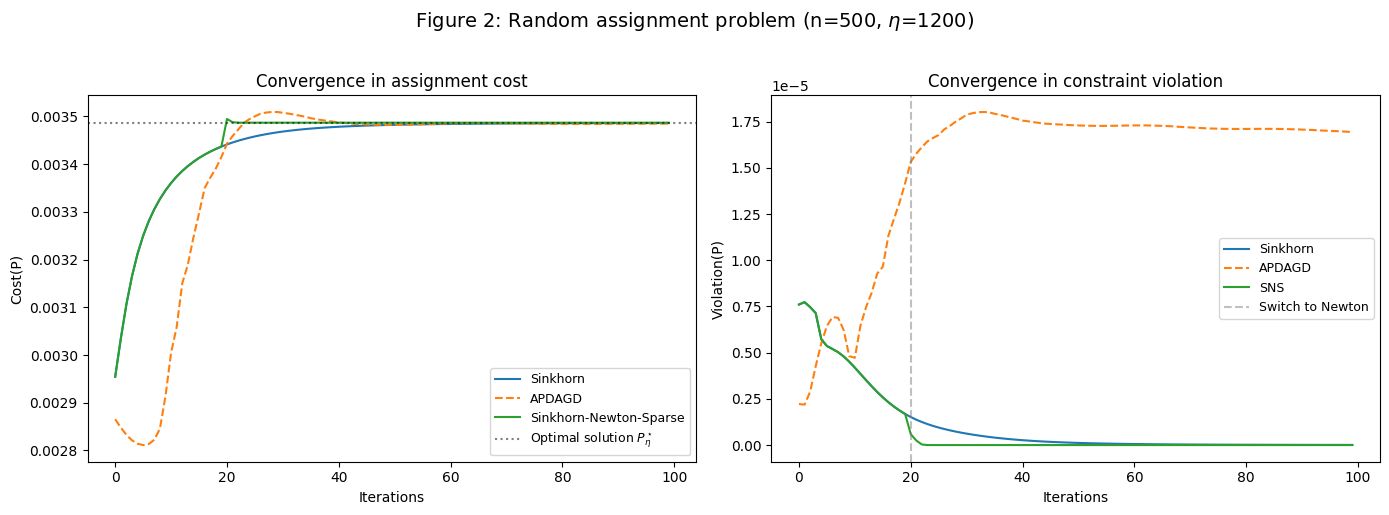

In [10]:
# =========================================================
# Figure 2: Cost(P) and Violation(P) convergence
# =========================================================
N1_switch = 20  # iteration where SNS switches to Newton

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Cost convergence (left) --
ax = axes[0]
ax.plot(hist_sink["cost"][:100], label="Sinkhorn", linewidth=1.5)
ax.plot(hist_apd["cost"][:100], label="APDAGD", linewidth=1.5, linestyle="--")
ax.plot(hist_sns["cost"][:100], label="Sinkhorn-Newton-Sparse", linewidth=1.5)

# Optimal solution line
opt_cost = float(jnp.sum(C * round_transport(P_ref, r, c)))
ax.axhline(opt_cost, color="black", linestyle=":", alpha=0.5, label=r"Optimal solution $P_\eta^\star$")

ax.set_xlabel("Iterations")
ax.set_ylabel("Cost(P)")
ax.set_title("Convergence in assignment cost")
ax.legend(fontsize=9)

# -- Violation convergence (right) --
ax = axes[1]
ax.plot(hist_sink["violation"][:100], label="Sinkhorn", linewidth=1.5)
ax.plot(hist_apd["violation"][:100], label="APDAGD", linewidth=1.5, linestyle="--")
ax.plot(hist_sns["violation"][:100], label="SNS", linewidth=1.5)
ax.axvline(N1_switch, color="gray", linestyle="--", alpha=0.5, label="Switch to Newton")

ax.set_xlabel("Iterations")
ax.set_ylabel("Violation(P)")
ax.set_title("Convergence in constraint violation")
ax.legend(fontsize=9)

fig.suptitle(r"Figure 2: Random assignment problem (n=500, $\eta$=1200)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

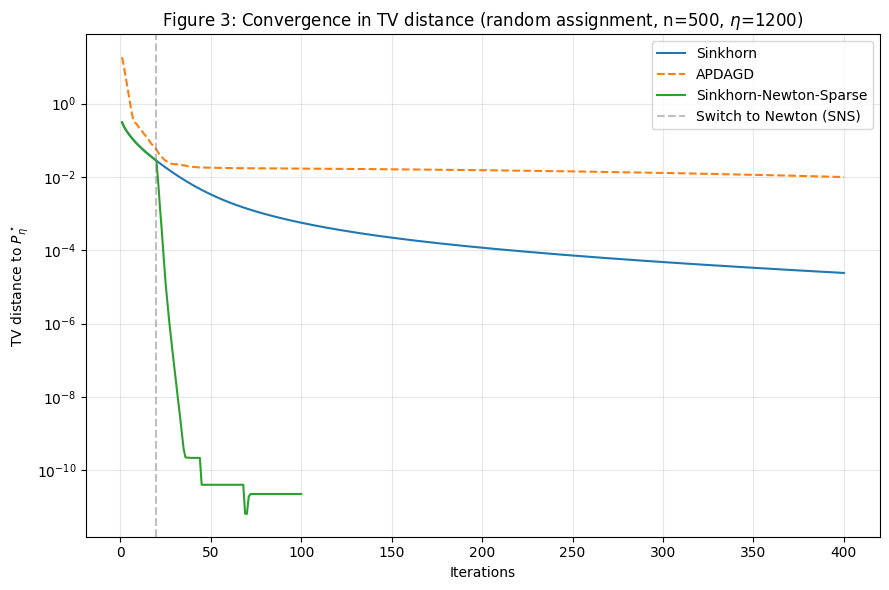

Final TV -- Sinkhorn: 2.41e-05, SNS: 2.27e-11, APDAGD: 9.93e-03


In [11]:
# =========================================================
# Figure 3: TV distance to P_eta* (iterations)
# =========================================================

# Recompute TV for SNS by re-running
tv_sns_list = []
x_t, y_t, a_t = jnp.zeros(n), jnp.zeros(n), jnp.zeros(K + L)

# Sinkhorn stage (N1=20)
for i in range(20):
    P_t = compute_P(x_t, y_t, a_t, C, Ds, eta)
    x_t = x_t + (jnp.log(r) - jnp.log(jnp.sum(P_t, axis=1).clip(1e-300))) / eta
    P_t = compute_P(x_t, y_t, a_t, C, Ds, eta)
    y_t = y_t + (jnp.log(c) - jnp.log(jnp.sum(P_t, axis=0).clip(1e-300))) / eta
    a_t, t_t = newton_constraint_update(x_t, y_t, a_t, C, Ds, r, c, eta, K, L, n_newton=3)
    x_t = x_t + t_t * jnp.ones(n)
    P_t = compute_P(x_t, y_t, a_t, C, Ds, eta)
    tv_sns_list.append(tv_distance(P_t, P_ref))

# Newton stage (N2=80)
M_dim = K + L
v = jnp.concatenate([jnp.ones(n), -jnp.ones(n), jnp.zeros(M_dim)])
z_t = jnp.concatenate([x_t, y_t, a_t])
z_t = z_t - (jnp.dot(z_t, v) / jnp.dot(v, v)) * v

for it in range(80):
    xt, yt, at = z_t[:n], z_t[n:2*n], z_t[2*n:]
    Pt = compute_P(xt, yt, at, C, Ds, eta)
    P1v = jnp.sum(Pt, axis=1)
    Pt1v = jnp.sum(Pt, axis=0)
    P_flat_sorted = jnp.sort(Pt.ravel())[::-1]
    keep = min(3 * n, n * n)
    rho_v = float(P_flat_sorted[keep - 1]) if keep < n * n else 0.0
    Ps = sparsify(Pt, rho_v)

    # Gradient
    gx = r - P1v
    gy = c - Pt1v
    ga = jnp.zeros(M_dim)
    for k_i in range(K):
        ga = ga.at[k_i].set(jnp.exp(-eta * at[k_i] - 1.0) - jnp.sum(Pt * Ds[k_i]))
    for l_i in range(L):
        ga = ga.at[K + l_i].set(-jnp.sum(Pt * Ds[K + l_i]))
    gf = jnp.concatenate([gx, gy, ga])
    rv = jnp.sum(xt) - jnp.sum(yt)
    greg = jnp.concatenate([-rv * jnp.ones(n), rv * jnp.ones(n), jnp.zeros(M_dim)])
    gft = gf + greg

    # Hessian
    dim = 2 * n + M_dim
    xa_b = jnp.zeros((n, M_dim))
    ya_b = jnp.zeros((n, M_dim))
    for m_i in range(M_dim):
        xa_b = xa_b.at[:, m_i].set(-eta * jnp.sum(Pt * Ds[m_i], axis=1))
        ya_b = ya_b.at[:, m_i].set(-eta * jnp.sum(Pt * Ds[m_i], axis=0))
    aa_b = jnp.zeros((M_dim, M_dim))
    for m_i in range(M_dim):
        for m_j in range(m_i, M_dim):
            vv = -eta * jnp.sum(Pt * Ds[m_i] * Ds[m_j])
            aa_b = aa_b.at[m_i, m_j].set(vv)
            if m_j > m_i:
                aa_b = aa_b.at[m_j, m_i].set(vv)
        if m_i < K:
            aa_b = aa_b.at[m_i, m_i].add(-eta * jnp.exp(-eta * at[m_i] - 1.0))
    Hm = jnp.zeros((dim, dim))
    Hm = Hm.at[:n, :n].set(-eta * jnp.diag(P1v))
    Hm = Hm.at[:n, n:2*n].set(-eta * Ps)
    Hm = Hm.at[n:2*n, :n].set(-eta * Ps.T)
    Hm = Hm.at[n:2*n, n:2*n].set(-eta * jnp.diag(Pt1v))
    Hm = Hm.at[:n, 2*n:].set(xa_b)
    Hm = Hm.at[n:2*n, 2*n:].set(ya_b)
    Hm = Hm.at[2*n:, :n].set(xa_b.T)
    Hm = Hm.at[2*n:, n:2*n].set(ya_b.T)
    Hm = Hm.at[2*n:, 2*n:].set(aa_b)
    Hm = Hm - jnp.outer(v, v)

    dz = -jnp.linalg.solve(Hm, gft)
    alpha_v = 1.0
    def ft_eval(zz):
        return dual_objective(zz[:n], zz[n:2*n], zz[2*n:], C, Ds, r, c, eta, K) - 0.5*(jnp.sum(zz[:n])-jnp.sum(zz[n:2*n]))**2
    fc = ft_eval(z_t)
    desc = jnp.dot(gft, dz)
    for _ls in range(30):
        zt_ = z_t + alpha_v * dz
        if ft_eval(zt_) >= fc + 1e-4 * alpha_v * desc:
            break
        alpha_v *= 0.5
    z_t = z_t + alpha_v * dz
    Pt = compute_P(z_t[:n], z_t[n:2*n], z_t[2*n:], C, Ds, eta)
    tv_sns_list.append(tv_distance(Pt, P_ref))

# APDAGD TV
tv_apd_list = []
z_a = jnp.zeros(2*n + M_dim)
zeta_a = jnp.zeros(2*n + M_dim)
alpha_a, beta_a, L_a = 0.0, 0.0, 1.0
for k_iter in range(400):
    M_a = L_a / 2.0
    for _inner in range(50):
        M_a = 2.0 * M_a
        al_new = (1.0 + jnp.sqrt(1.0 + 4.0*M_a*beta_a))/(2.0*M_a)
        be_new = beta_a + al_new
        tau_a = al_new / be_new
        lam_a = tau_a * zeta_a + (1.0-tau_a)*z_a
        gx_a, gy_a, ga_a, _ = compute_gradient(lam_a[:n], lam_a[n:2*n], lam_a[2*n:], C, Ds, r, c, eta, K, L)
        g_a = jnp.concatenate([gx_a, gy_a, ga_a])
        zeta_new = zeta_a + al_new * g_a
        z_new_a = tau_a * zeta_new + (1.0-tau_a)*z_a
        f_z_a = dual_objective(z_new_a[:n], z_new_a[n:2*n], z_new_a[2*n:], C, Ds, r, c, eta, K)
        f_l_a = dual_objective(lam_a[:n], lam_a[n:2*n], lam_a[2*n:], C, Ds, r, c, eta, K)
        diff_a = z_new_a - lam_a
        if f_z_a >= f_l_a + jnp.dot(g_a, diff_a) - (M_a/2.0)*jnp.dot(diff_a, diff_a):
            break
    L_a = M_a / 2.0
    z_a = z_new_a
    zeta_a = zeta_new
    alpha_a = al_new
    beta_a = be_new
    Pa = compute_P(z_a[:n], z_a[n:2*n], z_a[2*n:], C, Ds, eta)
    tv_apd_list.append(tv_distance(Pa, P_ref))

fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.semilogy(range(1, len(tv_sink)+1), tv_sink, label="Sinkhorn", linewidth=1.5)
ax.semilogy(range(1, len(tv_apd_list)+1), tv_apd_list, label="APDAGD", linewidth=1.5, linestyle="--")
ax.semilogy(range(1, len(tv_sns_list)+1), tv_sns_list, label="Sinkhorn-Newton-Sparse", linewidth=1.5)
ax.axvline(20, color="gray", linestyle="--", alpha=0.5, label="Switch to Newton (SNS)")
ax.set_xlabel("Iterations")
ax.set_ylabel(r"TV distance to $P_\eta^\star$")
ax.set_title(r"Figure 3: Convergence in TV distance (random assignment, n=500, $\eta$=1200)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final TV -- Sinkhorn: {tv_sink[-1]:.2e}, SNS: {tv_sns_list[-1]:.2e}, APDAGD: {tv_apd_list[-1]:.2e}")

In [ ]:
# ============================================================
# 0. Random instance generator
# ============================================================
def generate_random_instance(n, key, K=1, L=1):
    """Random OT instance with K inequality + L equality constraints."""
    k1, k2, k3 = jax.random.split(key, 3)
    C  = jax.random.uniform(k1, (n, n))
    r  = jnp.ones(n) / n
    c  = jnp.ones(n) / n
    DI = convert_leq_constraint(jax.random.uniform(k2, (n, n)), 0.5, n)
    DE = convert_eq_constraint( jax.random.uniform(k3, (n, n)), 0.5, n)
    Ds = jnp.stack([DI, DE])   # shape (K+L, n, n)
    return C, r, c, Ds, K, L

# ============================================================
# 1. SNS Newton step
# ============================================================
def sns_newton_step(x, y, a, C, Ds, r, c, eta, K, L):
    """A single sparse Newton step for the full variable (x, y, a)."""
    n     = x.shape[0]
    M_dim = K + L
    dim   = 2 * n + M_dim
    z     = jnp.concatenate([x, y, a])

    gx, gy, ga, Pt = compute_gradient(x, y, a, C, Ds, r, c, eta, K, L)
    gf  = jnp.concatenate([gx, gy, ga])

    v   = jnp.concatenate([jnp.ones(n), -jnp.ones(n), jnp.zeros(M_dim)])
    rv  = jnp.sum(x) - jnp.sum(y)
    gft = gf - rv * v

    P1v, Pt1v = jnp.sum(Pt, axis=1), jnp.sum(Pt, axis=0)
    keep = min(3 * n, n * n)
    rho  = float(jnp.sort(Pt.ravel())[::-1][keep - 1]) if keep < n * n else 0.0
    Ps   = jnp.where(Pt >= rho, Pt, 0.0)

    xa_b = jnp.zeros((n, M_dim))
    ya_b = jnp.zeros((n, M_dim))
    for m in range(M_dim):
        xa_b = xa_b.at[:, m].set(-eta * jnp.sum(Pt * Ds[m], axis=1))
        ya_b = ya_b.at[:, m].set(-eta * jnp.sum(Pt * Ds[m], axis=0))

    aa_b = jnp.zeros((M_dim, M_dim))
    for mi in range(M_dim):
        for mj in range(mi, M_dim):
            val = -eta * jnp.sum(Pt * Ds[mi] * Ds[mj])
            aa_b = aa_b.at[mi, mj].set(val)
            if mj > mi:
                aa_b = aa_b.at[mj, mi].set(val)
        if mi < K:
            aa_b = aa_b.at[mi, mi].add(-eta * jnp.exp(-eta * a[mi] - 1.0))

    Hm = jnp.zeros((dim, dim))
    Hm = Hm.at[:n,    :n   ].set(-eta * jnp.diag(P1v))
    Hm = Hm.at[:n,    n:2*n].set(-eta * Ps)
    Hm = Hm.at[n:2*n, :n   ].set(-eta * Ps.T)
    Hm = Hm.at[n:2*n, n:2*n].set(-eta * jnp.diag(Pt1v))
    Hm = Hm.at[:n,    2*n: ].set(xa_b)
    Hm = Hm.at[n:2*n, 2*n: ].set(ya_b)
    Hm = Hm.at[2*n:,  :n   ].set(xa_b.T)
    Hm = Hm.at[2*n:,  n:2*n].set(ya_b.T)
    Hm = Hm.at[2*n:,  2*n: ].set(aa_b)
    Hm = Hm - jnp.outer(v, v)

    dz      = -jnp.linalg.solve(Hm, gft)
    f_curr  = dual_objective(x, y, a, C, Ds, r, c, eta, K)
    descent = jnp.dot(gft, dz)
    alpha   = 1.0

    for _ in range(20):
        z_new = z + alpha * dz
        f_new = dual_objective(z_new[:n], z_new[n:2*n], z_new[2*n:],
                               C, Ds, r, c, eta, K)
        if f_new <= f_curr + 1e-4 * alpha * descent:
            break
        alpha *= 0.5

    if alpha < 1e-6:
        return x, y, a
    z_new = z + alpha * dz
    return z_new[:n], z_new[n:2*n], z_new[2*n:]

# ============================================================
# 2. Aggregation across random seeds
# ============================================================
n, eta  = 100, 1200
K, L    = 1, 1
N1, N2  = 20, 80
n_iters = N1 + N2
n_seeds = 50

all_tv_sns = []
print(f"Aggregating {n_seeds} seeds  (n={n}, eta={eta}) ...")

for seed in range(n_seeds):
    key = jax.random.PRNGKey(seed)
    C_s, r_s, c_s, Ds_s, K_s, L_s = generate_random_instance(n, key, K=K, L=L)

    _, _, _, P_ref_s, _ = constrained_sinkhorn(
        C_s, Ds_s, r_s, c_s, eta, K=K_s, L=L_s,
        n_iters=250, n_newton=5, verbose=False
    )

    x_s, y_s, a_s = jnp.zeros(n), jnp.zeros(n), jnp.zeros(K_s + L_s)
    tv_vals = []

    for i in range(n_iters):
        if i < N1:
            P_curr = compute_P(x_s, y_s, a_s, C_s, Ds_s, eta)
            x_s = x_s + (jnp.log(r_s) - jnp.log(jnp.sum(P_curr, axis=1).clip(1e-300))) / eta
            P_curr = compute_P(x_s, y_s, a_s, C_s, Ds_s, eta)
            y_s = y_s + (jnp.log(c_s) - jnp.log(jnp.sum(P_curr, axis=0).clip(1e-300))) / eta
            a_s, t_s = newton_constraint_update(x_s, y_s, a_s, C_s, Ds_s,
                                                r_s, c_s, eta, K_s, L_s)
            x_s = x_s + t_s * jnp.ones(n)
        else:
            if i == N1:
                v = jnp.concatenate([jnp.ones(n), -jnp.ones(n), jnp.zeros(K_s + L_s)])
                z = jnp.concatenate([x_s, y_s, a_s])
                z = z - (jnp.dot(z, v) / jnp.dot(v, v)) * v
                x_s, y_s, a_s = z[:n], z[n:2*n], z[2*n:]
            x_s, y_s, a_s = sns_newton_step(x_s, y_s, a_s, C_s, Ds_s,
                                             r_s, c_s, eta, K_s, L_s)

        P_iter = compute_P(x_s, y_s, a_s, C_s, Ds_s, eta)
        tv_vals.append(float(jnp.maximum(tv_distance(P_iter, P_ref_s), 1e-16)))

    all_tv_sns.append(tv_vals)
    if (seed + 1) % 10 == 0:
        print(f"  seed {seed+1:3d}/{n_seeds} | "
              f"TV after Sinkhorn: {tv_vals[N1-1]:.2e} | "
              f"TV after Newton:   {tv_vals[-1]:.2e}")

# ============================================================
# 3. Plot
# ============================================================
all_tv_sns = np.array(all_tv_sns)
iters  = np.arange(1, n_iters + 1)
median = np.median(all_tv_sns, axis=0)
q25    = np.percentile(all_tv_sns, 25, axis=0)
q75    = np.percentile(all_tv_sns, 75, axis=0)

plt.figure(figsize=(8, 6))
plt.semilogy(iters, median, color='tab:green', lw=2, label='SNS Median')
plt.fill_between(iters, q25, q75, color='tab:green', alpha=0.2, label='IQR 25–75%')
plt.axvline(N1, color="red", linestyle="--", label="Switch to Newton")
plt.xlabel("Iterations")
plt.ylabel(r"TV distance to $P_\eta^\star$")
plt.title(rf"SNS Performance over {n_seeds} Seeds ($n$={n}, $\eta$={eta})")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("figure4.png", dpi=150)
plt.show()

Aggregating 50 seeds...


## Experiment 2: 1D Transport under $\ell_2$ Constraint (Figure 1)

Reproducing **Figure 1** of the paper:
- Main cost = $\ell_1$ Manhattan distance: $c_1(x,y) = |x-y|$
- Inequality constraint on $\ell_2^2$ Euclidean distance: $\langle C_2, P\rangle \le t$
- By tuning $t$, the transport plan interpolates from minimising $\ell_2$ cost (binding constraint)
  to minimising $\ell_1$ cost (no constraint).

$$\min_{P \in \mathcal{U}_{r,c}} \langle C_1, P\rangle \quad\text{s.t.}\quad \langle C_2, P\rangle \le t$$

t_min (W2 distance) = 0.0275
t_max (L2 cost of L1-optimal plan) = 0.0310
[1/4] t=0.0275 | L1=0.1051, L2=0.0275, viol=5.73e-06
[2/4] t=0.0287 | L1=0.1060, L2=0.0287, viol=3.71e-06
[3/4] t=0.0298 | L1=0.1067, L2=0.0298, viol=1.95e-06
[4/4] t=0.0310 | L1=0.1074, L2=0.0310, viol=0.00e+00


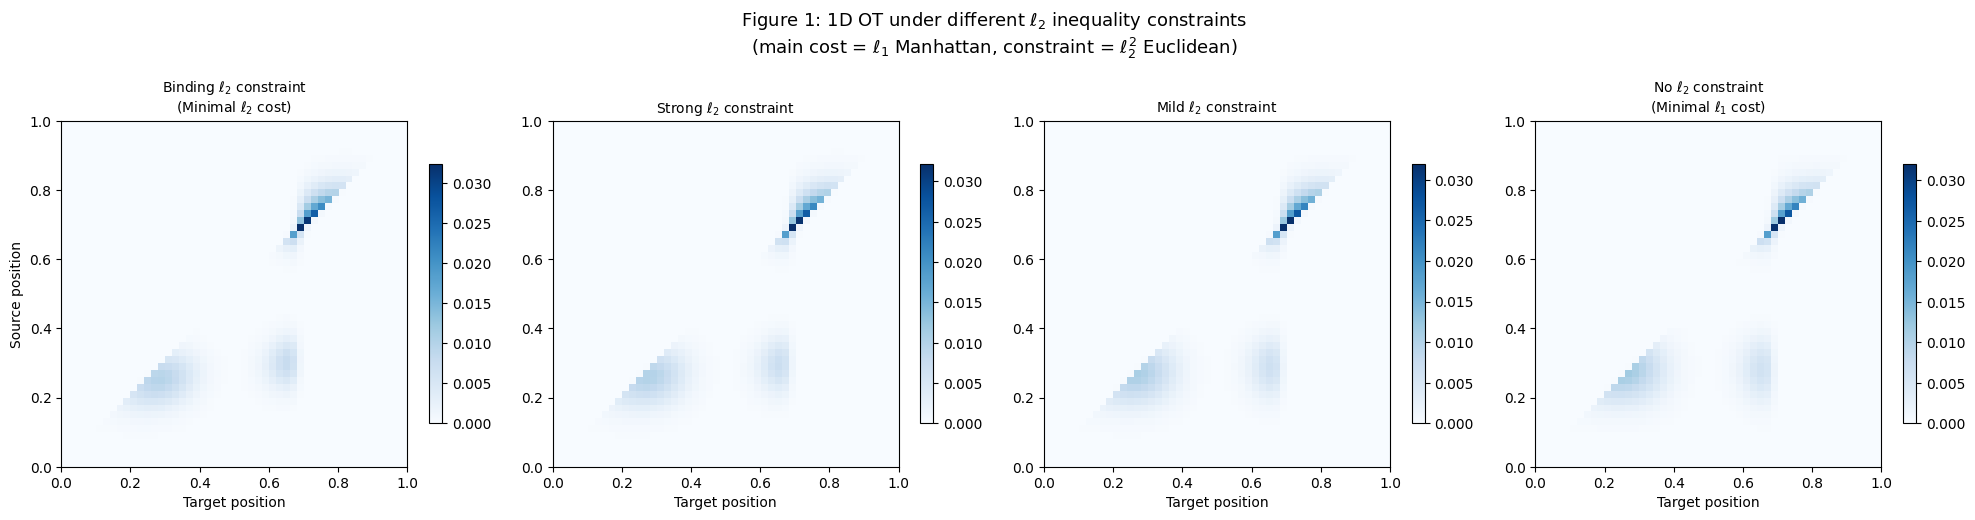

In [ ]:
# -- 1D distributions for Figure 1 --
n_1d = 50
grid = jnp.linspace(0, 1, n_1d)

# Simple source and target
def gaussian(x, mu, sigma):
    """Gaussian bump (un-normalised)."""
    p = jnp.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return p / p.sum()

# Source: bimodal
r_1d = 0.6 * gaussian(grid, 0.25, 0.06) + 0.4 * gaussian(grid, 0.75, 0.06)
r_1d = r_1d / r_1d.sum()

# Target: bimodal (shifted)
c_1d = 0.4 * gaussian(grid, 0.30, 0.06) + 0.6 * gaussian(grid, 0.70, 0.06)
c_1d = c_1d / c_1d.sum()

# Cost matrices
C1_1d = jnp.abs(grid[:, None] - grid[None, :])
C2_1d = (grid[:, None] - grid[None, :]) ** 2

eta_1d = 100

# -- Compute t_min (W2 distance) and t_max (L2 cost of W1-optimal plan) --
# These unconstrained references are solved directly with OTT-JAX Sinkhorn.
P_w2 = solve_ott_entropic_plan(C2_1d, r_1d, c_1d, eta_1d)
t_min = float(jnp.sum(C2_1d * P_w2))

P_w1 = solve_ott_entropic_plan(C1_1d, r_1d, c_1d, eta_1d)
t_max = float(jnp.sum(C2_1d * P_w1))

print(f"t_min (W2 distance) = {t_min:.4f}")
print(f"t_max (L2 cost of L1-optimal plan) = {t_max:.4f}")

# -- Solve for 4 threshold values: binding -> no constraint --
t_values = np.linspace(t_min, t_max, 4)
labels = [
    "Binding $\\ell_2$ constraint\n(Minimal $\\ell_2$ cost)",
    "Strong $\\ell_2$ constraint",
    "Mild $\\ell_2$ constraint",
    "No $\\ell_2$ constraint\n(Minimal $\\ell_1$ cost)"
]

plans_1d = []
for idx, t_val in enumerate(t_values):
    D_ineq = convert_leq_constraint(C2_1d, float(t_val), n_1d)
    _, _, _, P_cot, h = constrained_sinkhorn(
        C1_1d, [D_ineq], r_1d, c_1d, eta_1d,
        K=1, L=0, n_iters=200, n_newton=5, verbose=False
    )
    l1_cost = float(jnp.sum(C1_1d * P_cot))
    l2_cost = float(jnp.sum(C2_1d * P_cot))
    print(f"[{idx+1}/4] t={t_val:.4f} | L1={l1_cost:.4f}, L2={l2_cost:.4f}, "
          f"viol={h['violation'][-1]:.2e}")
    plans_1d.append(P_cot)

# -- Plot (reproducing Figure 1) --
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, (P_plan, label) in enumerate(zip(plans_1d, labels)):
    ax = axes[idx]
    im = ax.imshow(
        np.array(P_plan), cmap="Blues", origin="lower",
        extent=[0, 1, 0, 1], aspect="equal"
    )
    ax.set_xlabel("Target position")
    if idx == 0:
        ax.set_ylabel("Source position")
    ax.set_title(label, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.75)

fig.suptitle(
    "Figure 1: 1D OT under different $\\ell_2$ inequality constraints\n"
    "(main cost = $\\ell_1$ Manhattan, constraint = $\\ell_2^2$ Euclidean)",
    fontsize=13, y=1.06
)
plt.tight_layout()
plt.show()

## Experiment 3: Toy Pareto Front -- Manhattan vs. Squared Euclidean

Following Section 5 of the paper:

$$\min_{P \in \mathcal{U}_{r,c}} \langle C_1, P\rangle \quad\text{s.t.}\quad \langle C_2, P\rangle \le t$$

By sweeping $t \in [t_{min}, t_{max}]$ for different $\eta \in \{10, 100, 1000\}$, we trace Pareto fronts between
$\ell_1$ and $\ell_2^2$ transport cost. As $\eta$ increases, the front converges to the true Pareto front.

eta = 10: done
eta = 100: done
eta = 1000: done
True Pareto (eta=5000): done


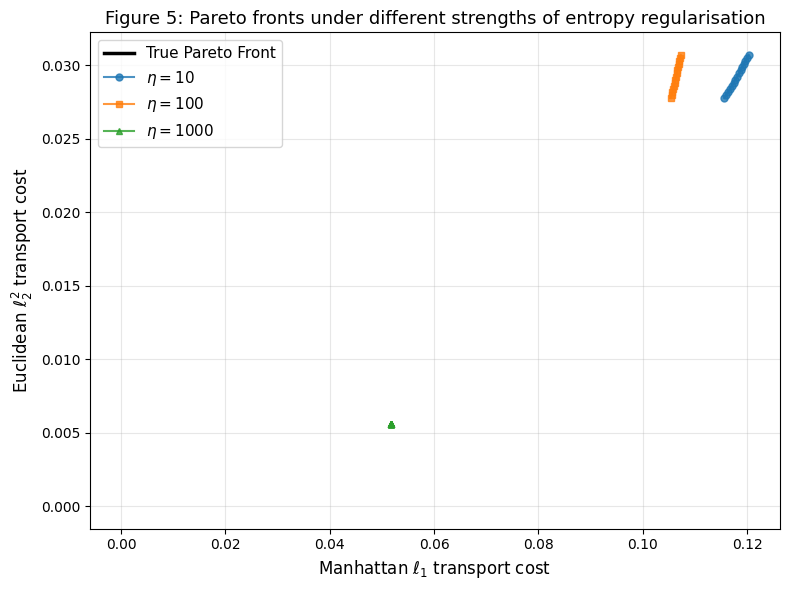

In [13]:
# -- Pareto front profiling (Figure 5) --
t_sweep = np.linspace(t_min * 1.01, t_max * 0.99, 15)

pareto_data = {}
for eta_p in [10, 100, 1000]:
    costs_l1, costs_l2 = [], []
    for t_val in t_sweep:
        D_ineq = convert_leq_constraint(C2_1d, float(t_val), n_1d)
        _, _, _, P_p, _ = constrained_sinkhorn(
            C1_1d, [D_ineq], r_1d, c_1d, eta_p,
            K=1, L=0, n_iters=200, n_newton=5, verbose=False
        )
        costs_l1.append(float(jnp.sum(C1_1d * P_p)))
        costs_l2.append(float(jnp.sum(C2_1d * P_p)))
    pareto_data[eta_p] = (costs_l1, costs_l2)
    print(f"eta = {eta_p}: done")

# "True" Pareto front at very high eta
costs_l1_true, costs_l2_true = [], []
eta_true = 5000
for t_val in t_sweep:
    D_ineq = convert_leq_constraint(C2_1d, float(t_val), n_1d)
    _, _, _, P_p, _ = constrained_sinkhorn(
        C1_1d, [D_ineq], r_1d, c_1d, eta_true,
        K=1, L=0, n_iters=300, n_newton=5, verbose=False
    )
    costs_l1_true.append(float(jnp.sum(C1_1d * P_p)))
    costs_l2_true.append(float(jnp.sum(C2_1d * P_p)))
print(f"True Pareto (eta={eta_true}): done")

# -- Plot (reproducing Figure 5) --
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(costs_l1_true, costs_l2_true, "k-", linewidth=2.5, label="True Pareto Front", zorder=5)

markers = ["o", "s", "^"]
for (eta_p, (cl1, cl2)), marker in zip(pareto_data.items(), markers):
    ax.plot(cl1, cl2, f"-{marker}", linewidth=1.5, markersize=5, label=f"$\\eta = {eta_p}$", alpha=0.8)

ax.set_xlabel("Manhattan $\\ell_1$ transport cost", fontsize=12)
ax.set_ylabel("Euclidean $\\ell_2^2$ transport cost", fontsize=12)
ax.set_title("Figure 5: Pareto fronts under different strengths of entropy regularisation", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

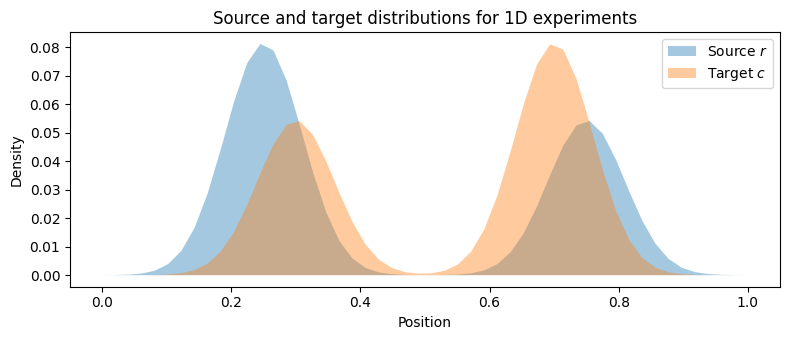

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(np.array(grid), 0, np.array(r_1d), alpha=0.4, label="Source $r$")
ax.fill_between(np.array(grid), 0, np.array(c_1d), alpha=0.4, label="Target $c$")
ax.set_xlabel("Position")
ax.set_ylabel("Density")
ax.set_title("Source and target distributions for 1D experiments")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

This tutorial demonstrats how to leverage OTT-JAX to solve constrained optimal transport problems efficiently using the algorithms introduced in the paper. By using the Geometry class to encode dual shifts, we can seamlessly integrate additional linear constraints into the Sinkhorn loop.